Full clustering analysis on tweet data from the cnnhealth.txt data set.



In [15]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

#loading data
input_file = "cnnhealth.txt"   

with open(input_file, "r", encoding="utf-8") as f:
    lines = [re.sub(r"\|\s+", " ", line) for line in f]

df = pd.read_csv(pd.io.common.StringIO("".join(lines)), sep="|", header=None)
df.columns = ["id", "timestamp", "text"]

#remove duplicates
df["urls"] = df["text"].apply(lambda x: re.findall(r"http\S+|www\S+", str(x)))

# keep only the first tweet per unique URL
url_to_keep = {}
indices_to_drop = set()

for idx, url_list in enumerate(df["urls"]):
    for url in url_list:
        if url in url_to_keep:
            indices_to_drop.add(idx)  # duplicate URL, mark for removal
        else:
            url_to_keep[url] = idx    # first occurrence

df = df.drop(index=list(indices_to_drop)).reset_index(drop=True)

# remove temporary 'urls' column
df = df.drop(columns=["urls"])

print(f"Removed {len(indices_to_drop)} tweets due to duplicate URLs. Remaining: {len(df)}")
#cleaning

def clean_text(text):
    text = str(text)
    
    # remove leading 'RT ' at the beginning
    text = re.sub(r"^\s*rt\s+", "", text, flags=re.IGNORECASE)
    
    # remove all other instances of ' rt ' (with spaces around)
    text = re.sub(r"\s+rt\s+", " ", text, flags=re.IGNORECASE)
    
    # remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # remove mentions
    text = re.sub(r"@\w+", "", text)
    
    # remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)
    
    # remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # convert to lowercase
    text = text.lower()
    
    # remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["clean_text"] = df["text"].apply(clean_text)
before = len(df)
df = df.drop_duplicates(subset="clean_text", keep="first").reset_index(drop=True)
after = len(df)

#taking care of the trailing via
df["clean_text_stripped"] = df["clean_text"].str.replace(r"\s+via(\s+@\w+)?$", "", regex=True)

#removing dupes based on the via
before_dupes = len(df)
df = df.drop_duplicates(subset="clean_text_stripped", keep="first").reset_index(drop=True)
after_dupes = len(df)

print(f"Removed {before_dupes - after_dupes} duplicate tweets due to trailing 'via'. Remaining: {after_dupes}")
df = df.drop(columns=["clean_text_stripped"])

#vectorization

USE_TFIDF = True   #set to false for raw counts

if USE_TFIDF:
    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2),   # unigrams + bigrams
        min_df=2              # ignore very rare words
    )
else:
    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2
    )

X = vectorizer.fit_transform(df["clean_text"])

mask = (X.sum(axis=1) > 0).A1
X = X[mask]
df = df[mask].reset_index(drop=True)

#step 4: Save outputs
from scipy.sparse import save_npz
from scipy.io import mmwrite
save_npz("tweet_features.npz", X)
mmwrite("tweet_features.mtx", X)

df["clean_text"].to_csv("cleaned_tweets.txt", index=False, header=False)

#a few sanity checks


feature_names = vectorizer.get_feature_names_out()
row_sums = X.sum(axis=1)
num_docs, num_features = X.shape
avg_nonzero = X.nnz / num_docs

# sparsity
sparsity = 1 - (X.nnz / (num_docs * num_features))

print("Documents:", num_docs)
print("Features:", num_features)
print("Avg nonzeros per doc:", avg_nonzero)
print("Sparsity:", sparsity)

Removed 288 tweets due to duplicate URLs. Remaining: 3769
Removed 3 duplicate tweets due to trailing 'via'. Remaining: 3718
Documents: 3709
Features: 4189
Avg nonzeros per doc: 6.760043138312214
Sparsity: 0.9983862394036017


After parsing and cleaning the dataset, as well as vectorizing the tweet data, we can define our distance measures.

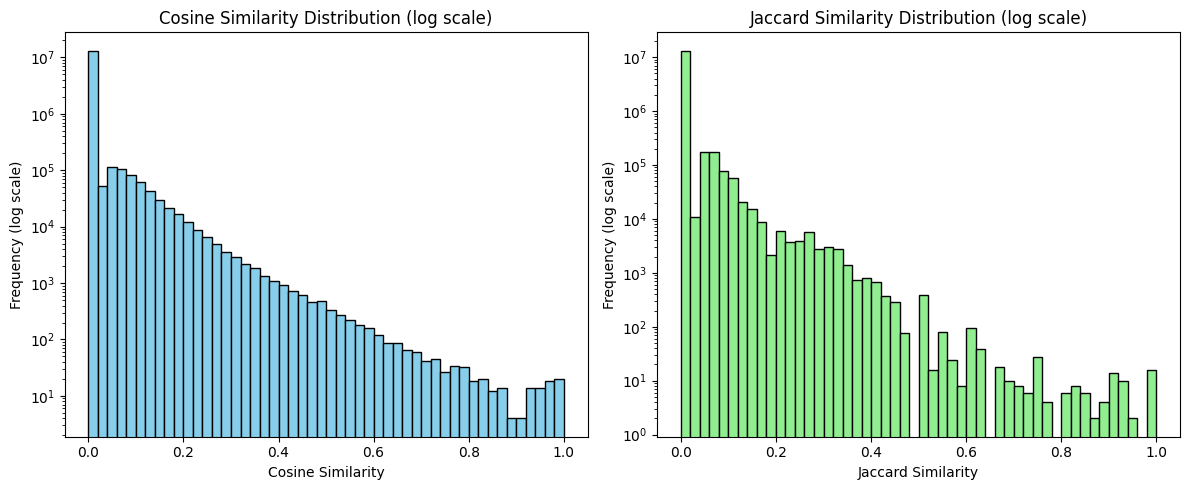

In [16]:
import numpy as np
from scipy.sparse import load_npz
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

#feature matrix
X = load_npz("tweet_features.npz")

#cosine similarity
cos_sim = cosine_similarity(X)
np.savetxt("cosine_similarity.txt", cos_sim)

#jaccard similarity, binarize the matrix so it doesn't take a year to run
X_bin = (X > 0).astype(int)  # binarize
intersection = X_bin @ X_bin.T
row_sums = X_bin.sum(axis=1).A1
union = row_sums[:, None] + row_sums[None, :] - intersection.toarray()
jaccard_sim = intersection.toarray() / union
np.savetxt("jaccard_similarity.txt", jaccard_sim)

# Removes the 1.0 similarities along the diagonals
nondiagonal_mask = np.ones(cos_sim.shape, dtype=bool)
np.fill_diagonal(nondiagonal_mask, False)
cos_vals = cos_sim[nondiagonal_mask]
jac_vals = jaccard_sim[nondiagonal_mask]

#histograms with a log scale
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(cos_vals.flatten(), bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Cosine Similarity Distribution (log scale)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency (log scale)")

plt.subplot(1,2,2)
plt.hist(jac_vals.flatten(), bins=50, color='lightgreen', edgecolor='black', log=True)
plt.title("Jaccard Similarity Distribution (log scale)")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()

Now that we have the distance measures we can do each of the clustering methods.
Spherical K-means clustering on the cosine similarity distance measure. 

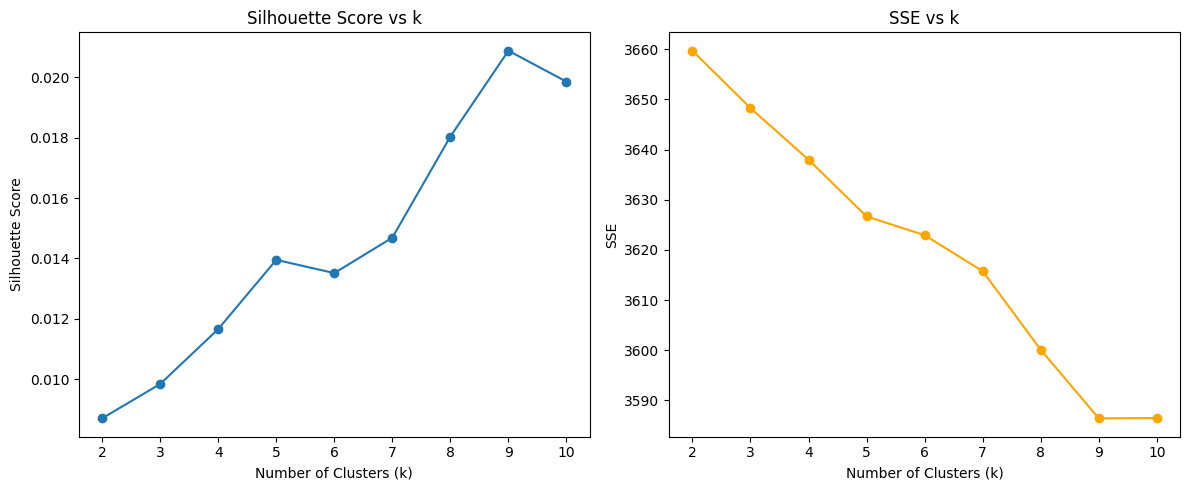

Optimal number of clusters based on silhouette score: 9
Cluster sizes:
Cluster 0: 2632 tweets
Cluster 1: 92 tweets
Cluster 2: 101 tweets
Cluster 3: 156 tweets
Cluster 4: 105 tweets
Cluster 5: 132 tweets
Cluster 6: 151 tweets
Cluster 7: 209 tweets
Cluster 8: 131 tweets


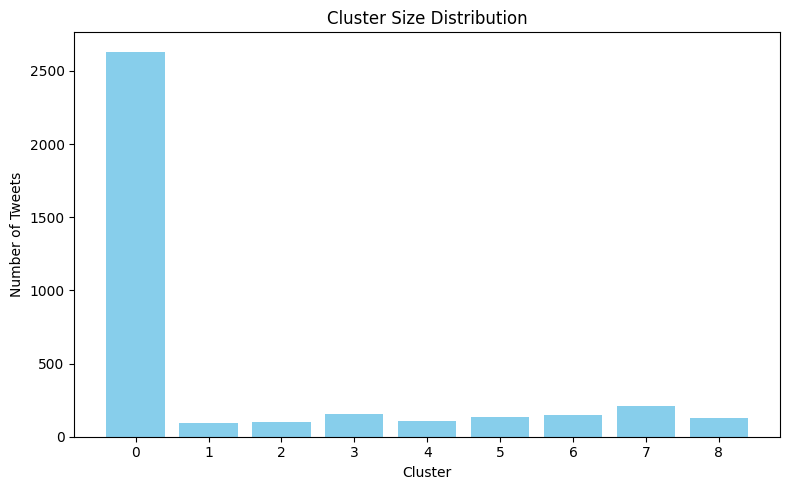

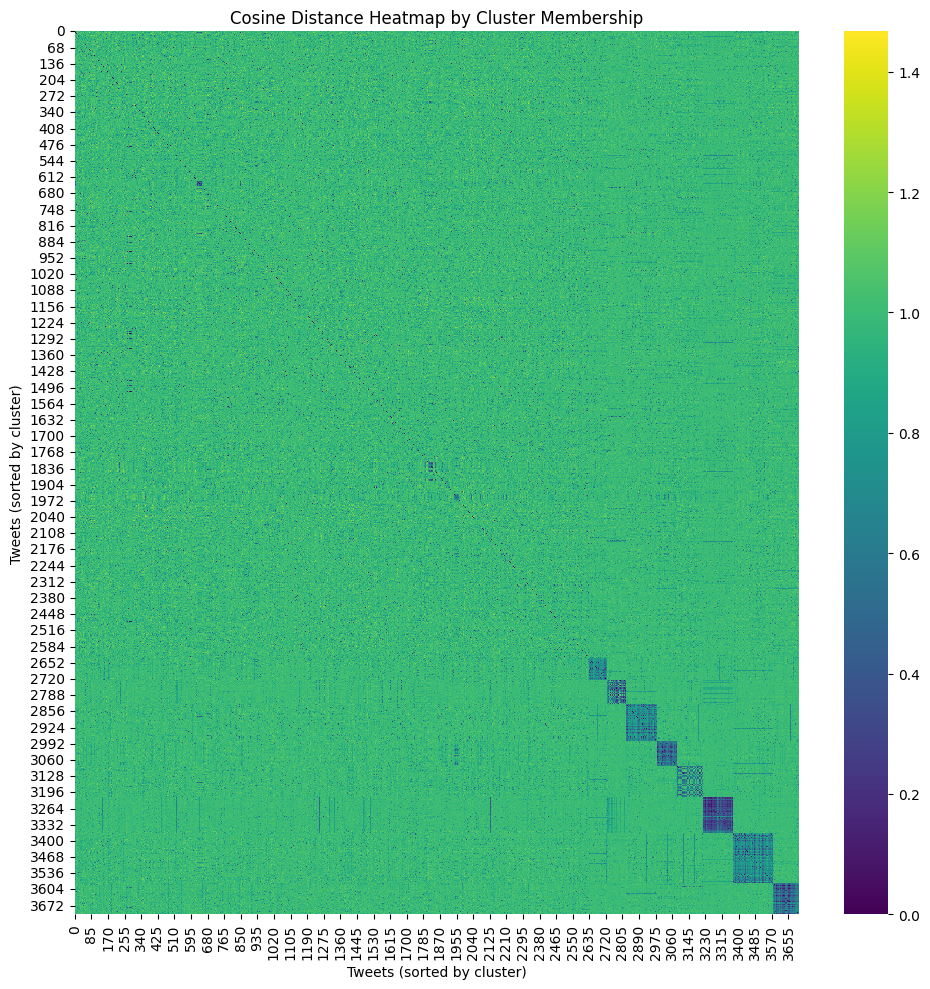

Largest cluster ID: 0, size: 2632
Top 10 words in cluster:
         word      score
1992     kids  28.249909
3178     says  25.604385
365     brain  22.373933
120       amp  19.970412
1681     help  19.424162
1647  healthy  19.319577
1353      flu  17.122751
2235     make  16.226273
1372     food  16.142512
2309  medical  14.762608

final metrics:
Silhouette Score: 0.0209
SSE (Cohesion): 3586.4181
BSS (Separation): 105.3929
Total Entropy (proxy): 9.7111
Total Purity (proxy): 0.0075


In [17]:
import numpy as np
import pandas as pd
from scipy.sparse import load_npz
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from collections import Counter
import warnings
warnings.filterwarnings("ignore")


#load feature matrix
X = load_npz("tweet_features.npz")
feature_names = np.loadtxt("feature_names.txt", dtype=str, delimiter="\t")

#normalize to do spherical
X_normalized = normalize(X, norm='l2', axis=1)
X_reduced = TruncatedSVD(n_components=100, random_state=42).fit_transform(X_normalized)

#cosine similarity matrix
cos_sim = cosine_similarity(X_reduced)
cos_dist = 1 - cos_sim  # convert similarity to distance for SSE/BSS

max_k = 10
sil_scores = []
SSE = []

for k in range(2, max_k+1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_normalized)
    
    # silhouette (cosine metric works on sparse)
    score = silhouette_score(X_normalized, labels, metric='cosine')
    sil_scores.append(score)
    
    # SSE for sparse matrix
    sse = 0
    for cluster_id in range(k):
        cluster_points = X_normalized[labels == cluster_id]
        center = kmeans.cluster_centers_[cluster_id]
        sse += np.sum((cluster_points.toarray() - center)**2)
    SSE.append(sse)

#sillouhette and sse based on cluster size
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(2, max_k+1), sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")

plt.subplot(1,2,2)
plt.plot(range(2, max_k+1), SSE, marker='o', color='orange')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.title("SSE vs k")

plt.tight_layout()
plt.savefig("kmeans_cluster_quality_metrics.png")
plt.show()

#pick the k with highest sillhouette score
best_k = np.argmax(sil_scores) + 2
print(f"Optimal number of clusters based on silhouette score: {best_k}")

#run k means spherical
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_normalized)
np.savetxt("tweet_clusters.txt", labels_final, fmt='%d')

#distribution of cluster sizes
unique, counts = np.unique(labels_final, return_counts=True)
print("Cluster sizes:")
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} tweets")

plt.figure(figsize=(8,5))
plt.bar(unique, counts, color='skyblue')
plt.xlabel("Cluster")
plt.ylabel("Number of Tweets")
plt.title("Cluster Size Distribution")
plt.xticks(unique)
plt.tight_layout()
plt.savefig("kmeans_cluster_size_distribution.png")
plt.show()

# reorder for heatmap
sorted_idx = np.argsort(labels_final)
sorted_dist = cos_dist[sorted_idx][:, sorted_idx]

plt.figure(figsize=(10,10))
sns.heatmap(sorted_dist, cmap="viridis")
plt.title("Cosine Distance Heatmap by Cluster Membership")
plt.xlabel("Tweets (sorted by cluster)")
plt.ylabel("Tweets (sorted by cluster)")
plt.tight_layout()
plt.savefig("kmeans_cluster_heatmap.png")
plt.show()

#cluster selection
unique, counts = np.unique(labels_final, return_counts=True)
largest_cluster = unique[np.argmax(counts)]
print(f"Largest cluster ID: {largest_cluster}, size: {np.max(counts)}")

#tweet indices
cluster_idx = np.where(labels_final == largest_cluster)[0]

#sum all the feature counts
cluster_matrix = X[cluster_idx]   # sparse matrix of cluster tweets
word_sums = np.array(cluster_matrix.sum(axis=0)).flatten()
word_freq = pd.DataFrame({'word': feature_names, 'score': word_sums})

#get top 10 words
top_words = word_freq.sort_values('score', ascending=False).head(10)
print("Top 10 words in cluster:")
print(top_words)

labels_pred = labels_final
num_clusters = len(np.unique(labels_pred))
N = len(labels_pred)

silhouette_final = silhouette_score(X_normalized, labels_final, metric='cosine')

# overall sse
SSE_total = 0
for cluster_id in range(best_k):
    cluster_points = X_normalized[labels_final == cluster_id]
    center = kmeans_final.cluster_centers_[cluster_id]
    SSE_total += np.sum((cluster_points.toarray() - center)**2)

# bss calc
# global mean
X_dense = X_normalized.toarray()
global_center = X_dense.mean(axis=0)

BSS_total = 0
for cluster_id in range(best_k):
    idx = np.where(labels_final == cluster_id)[0]
    cluster_points = X_dense[idx]
    cluster_center = cluster_points.mean(axis=0)
    n_k = len(idx)
    
    BSS_total += n_k * np.sum((cluster_center - global_center)**2)

#print final metrics
print("\nfinal metrics:")
print(f"Silhouette Score: {silhouette_final:.4f}")
print(f"SSE (Cohesion): {SSE_total:.4f}")
print(f"BSS (Separation): {BSS_total:.4f}")

entropy_total = 0
purity_total = 0

# Use top word in each tweet as proxy "true label"
# Convert sparse matrix to dense for word lookup
X_dense = X.toarray()
top_words_per_tweet = [feature_names[np.argmax(row)] for row in X_dense]

for k in range(num_clusters):
    idx = np.where(labels_pred == k)[0]
    cluster_size = len(idx)
    
    # Get the top words for tweets in this cluster
    words_in_cluster = [top_words_per_tweet[i] for i in idx]
    
    counts = np.array(list(Counter(words_in_cluster).values()))
    probs = counts / counts.sum()

    # entropy for this cluster
    H = -np.sum(probs * np.log2(probs))
    entropy_total += (cluster_size / N) * H

    # purity for this cluster
    purity_total += (cluster_size / N) * probs.max()

print(f"Total Entropy (proxy): {entropy_total:.4f}")
print(f"Total Purity (proxy): {purity_total:.4f}")

Now we can do DBscan clustering on the Jaccard distance measure.


final metrics
Silhouette Score: 0.0088
SSE (Cohesion): 1199.0636
BSS (Separation): 122.6373
Number of clusters (excluding noise): 44
Number of clusters: 44


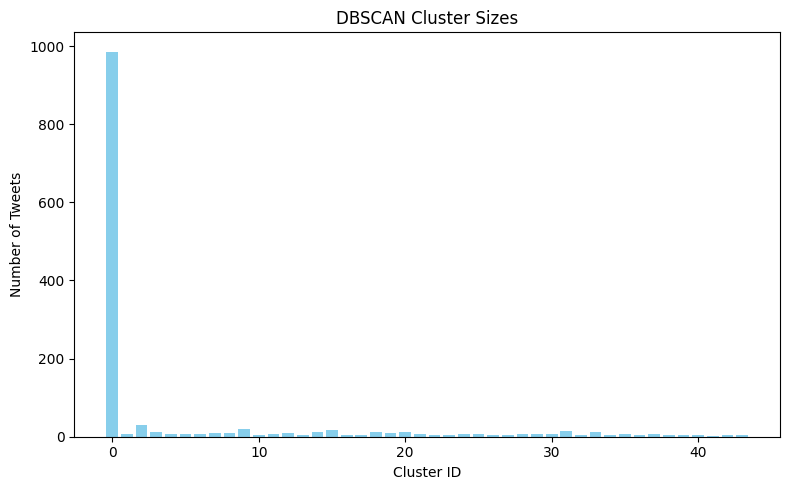

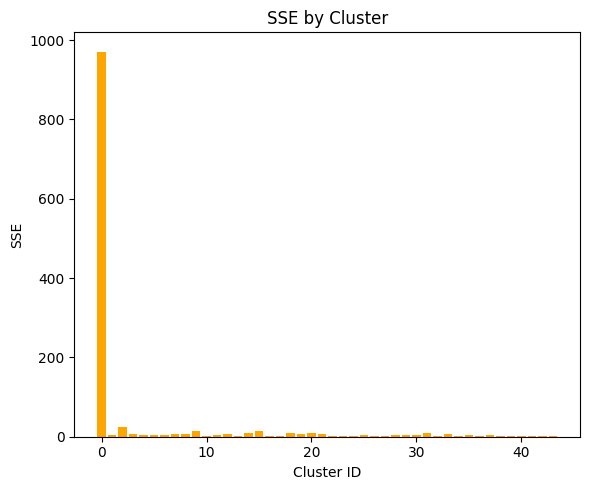

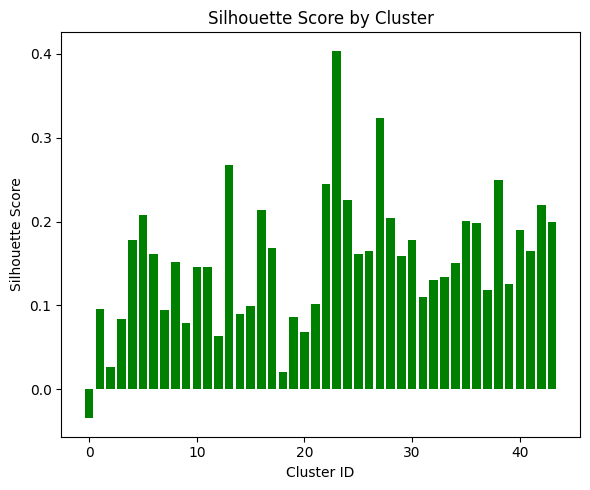

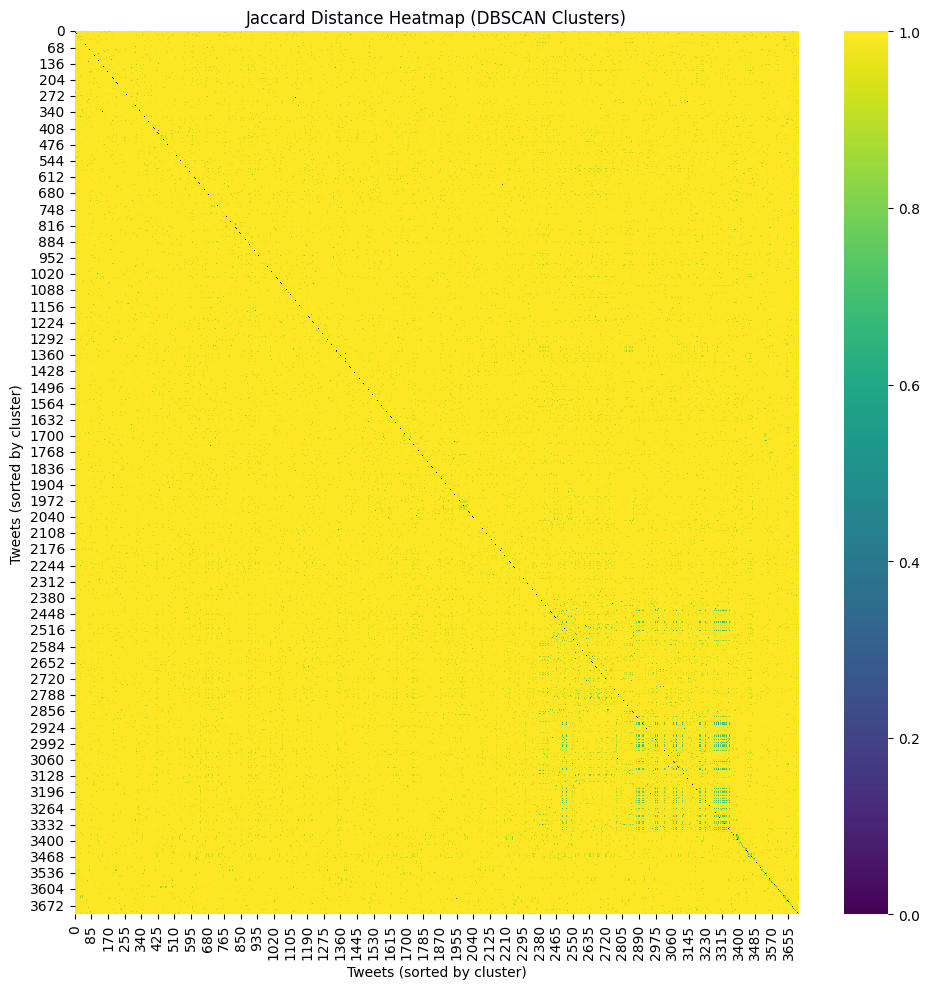

In [18]:
import numpy as np
from scipy.sparse import load_npz
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
from sklearn.metrics import silhouette_samples
import warnings
warnings.filterwarnings("ignore")

#feature matrix and binarized version for jaccard
X = load_npz("tweet_features.npz")
X_bin = (X > 0).astype(int)

#do the jaccard similarity manually
intersection = X_bin @ X_bin.T
row_sums = X_bin.sum(axis=1).A1
union = row_sums[:, None] + row_sums[None, :] - intersection.A
jaccard_sim = intersection.A / union
jaccard_dist = 1 - jaccard_sim  # distance matrix

dists = jaccard_dist[np.triu_indices_from(jaccard_dist, k=1)]
#we chose eps by looking at a graph of the sorted distances and picking a value that seemed 
#to separate the lower distances from the higher ones
eps = .77  

#dbscan
min_samples = 5
db = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
labels = db.fit_predict(jaccard_dist)

valid_idx = np.where(labels != -1)[0]
labels_valid = labels[valid_idx]

# only compute if we have at least 2 clusters
n_clusters = len(set(labels_valid))

if n_clusters > 1:
    # overall silhouette score
    sil_samples = silhouette_samples(jaccard_dist[valid_idx][:, valid_idx], 
                                     labels_valid, 
                                     metric='precomputed')
    silhouette_final = np.mean(sil_samples)
else:
    silhouette_final = np.nan

#overall sse
SSE_total = 0
X_dense = X.toarray()

cluster_ids = [u for u in np.unique(labels) if u != -1]

for u in cluster_ids:
    idx = np.where(labels == u)[0]
    cluster_points = X_dense[idx]
    center = cluster_points.mean(axis=0)
    SSE_total += np.sum((cluster_points - center) ** 2)

#overall bss
global_center = X_dense.mean(axis=0)

BSS_total = 0
for u in cluster_ids:
    idx = np.where(labels == u)[0]
    cluster_points = X_dense[idx]
    cluster_center = cluster_points.mean(axis=0)
    n_k = len(idx)
    
    BSS_total += n_k * np.sum((cluster_center - global_center) ** 2)

#print metrics
print("\nfinal metrics")
print(f"Silhouette Score: {silhouette_final:.4f}")
print(f"SSE (Cohesion): {SSE_total:.4f}")
print(f"BSS (Separation): {BSS_total:.4f}")
print(f"Number of clusters (excluding noise): {n_clusters}")

#summary of clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Number of clusters: {n_clusters}")

#cluster sizes vizualization
plt.figure(figsize=(8,5))
unique, counts = np.unique(labels, return_counts=True)
cluster_sizes = [c for u,c in zip(unique, counts) if u != -1]
cluster_ids = [u for u in unique if u != -1]
plt.bar(cluster_ids, cluster_sizes, color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Tweets")
plt.title("DBSCAN Cluster Sizes")
plt.tight_layout()
plt.savefig("dbscan_cluster_sizes.png")

#compute sse and silhouette scores
if len(set(labels)) > 1 and len(set(labels)) - (1 if -1 in labels else 0) > 1:
    sil_samples = silhouette_samples(jaccard_dist, labels, metric='precomputed')
    sil_list = []
    for u in cluster_ids:
        idx = np.where(labels == u)[0]
        sil_list.append(sil_samples[idx].mean())
else:
    sil_list = [np.nan]*len(cluster_ids)

#compute SSE
sse_list = []
for u in cluster_ids:
    idx = np.where(labels == u)[0]
    cluster_points = X[idx].toarray()
    center = cluster_points.mean(axis=0)
    sse = np.sum((cluster_points - center) ** 2)
    sse_list.append(sse)

#visualize SSE
plt.figure(figsize=(6,5))
plt.bar(cluster_ids, sse_list, color='orange')
plt.xlabel("Cluster ID")
plt.ylabel("SSE")
plt.title("SSE by Cluster")
plt.tight_layout()
plt.savefig("dbscan_sse.png")

#visualize silhouette using the sil_samples computed earlier
plt.figure(figsize=(6,5))
plt.bar(cluster_ids, sil_list, color='green')
plt.xlabel("Cluster ID")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Cluster")
plt.tight_layout()
plt.savefig("dbscan_silhouette.png")

#heatmap
sorted_idx = np.argsort(labels)
sorted_dist = jaccard_dist[sorted_idx][:, sorted_idx]
plt.figure(figsize=(10,10))
sns.heatmap(sorted_dist, cmap="viridis")
plt.title("Jaccard Distance Heatmap (DBSCAN Clusters)")
plt.xlabel("Tweets (sorted by cluster)")
plt.ylabel("Tweets (sorted by cluster)")
plt.tight_layout()
plt.savefig("dbscan_heatmap.png")
plt.show()
#save the labels
np.savetxt("dbscan_tweet_clusters.txt", labels, fmt='%d')


